# Cauchy Distribution

The **Cauchy distribution** looks like a Normal distribution with much heavier tails. It is the classic example of a distribution with **no finite mean or variance** — making it pathological from a classical statistics standpoint, but extremely useful for stress-testing robust methods.

| Property | Value |
|---|---|
| **Parameters** | t (location), s (scale, s > 0) |
| **Support** | (−∞, +∞) |
| **PDF** | f(x) = 1 / (πs[1 + ((x−t)/s)²]) |
| **CDF** | F(x) = 0.5 + arctan((x−t)/s) / π |
| **Mean** | **Undefined** (integral diverges) |
| **Variance** | **Undefined** |
| **Median** | t |
| **Mode** | t |
| **Skewness** | 0 (symmetric, but undefined in the classical sense) |
| **Kurtosis** | Undefined |
| **Parameter estimation** | MLE or sample median (not sample mean — it doesn't converge) |

> **Key insight**: collecting 1,000 data points gives no more accurate an estimate of the mean than a single point — the sample mean does not converge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

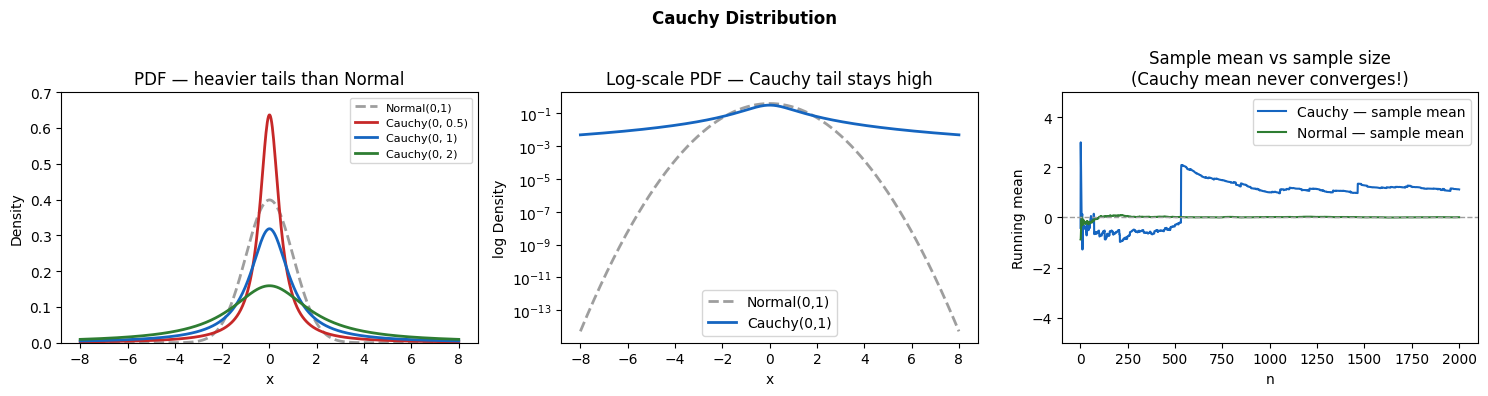

In [2]:
x = np.linspace(-8, 8, 600)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cauchy Distribution', fontsize=12, fontweight='bold')

# PDF vs Normal
axes[0].plot(x, stats.norm(0, 1).pdf(x), color='#9E9E9E', linewidth=2, linestyle='--', label='Normal(0,1)')
for s, color, label in [(0.5, '#C62828', 'Cauchy(0, 0.5)'),
                         (1,   '#1565C0', 'Cauchy(0, 1)'),
                         (2,   '#2E7D32', 'Cauchy(0, 2)')]:
    axes[0].plot(x, stats.cauchy(0, s).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — heavier tails than Normal')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.7)
axes[0].legend(fontsize=8)

# Heavy tail comparison (log scale)
axes[1].semilogy(x, stats.norm(0, 1).pdf(x), color='#9E9E9E', linewidth=2, linestyle='--', label='Normal(0,1)')
axes[1].semilogy(x, stats.cauchy(0, 1).pdf(x), color='#1565C0', linewidth=2, label='Cauchy(0,1)')
axes[1].set_title('Log-scale PDF — Cauchy tail stays high')
axes[1].set_xlabel('x'); axes[1].set_ylabel('log Density')
axes[1].legend()

# Sample mean does NOT converge (law of large numbers fails)
np.random.seed(42)
n_max = 2000
cauchy_data = stats.cauchy.rvs(size=n_max)
normal_data = stats.norm.rvs(size=n_max)
ns = np.arange(1, n_max+1)
axes[2].plot(ns, np.cumsum(cauchy_data)/ns, color='#1565C0', linewidth=1.5, label='Cauchy — sample mean')
axes[2].plot(ns, np.cumsum(normal_data)/ns, color='#2E7D32', linewidth=1.5, label='Normal — sample mean')
axes[2].axhline(0, color='#9E9E9E', linewidth=1, linestyle='--')
axes[2].set_title('Sample mean vs sample size\n(Cauchy mean never converges!)')
axes[2].set_xlabel('n'); axes[2].set_ylabel('Running mean')
axes[2].set_ylim(-5, 5)
axes[2].legend()

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **No mean/variance** | All moments are undefined — the sample mean never converges |
| **Heavy tails** | Tail decays as 1/x² vs Normal's e^(−x²) — extreme values are far more likely |
| **Symmetric** | Median = mode = location t; visually looks like a fat Normal |
| **Pathological** | Law of Large Numbers and CLT do not apply |
| **Robustness testing** | Used to stress-test procedures under heavy-tailed contamination |
| **Use median** | Sample median is a consistent estimator of t; sample mean is not |
| **Physics** | Models resonance phenomena and ratio of two independent standard normals |